<a href="https://colab.research.google.com/github/machancejoy-max/colab-git-demo-JOY/blob/main/Assignment12.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [2]:
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from tensorflow import keras
from tensorflow.keras import layers, models
from sklearn.metrics import classification_report, confusion_matrix

plt.style.use("seaborn-v0_8")


In [3]:
# 1. Load Fashion-MNIST dataset
# Fashion-MNIST: 28x28 grayscale images, 10 classes
(x_train, y_train), (x_test, y_test) = keras.datasets.fashion_mnist.load_data()

print("Train shape:", x_train.shape, "Test shape:", x_test.shape)

class_names = [
    "T-shirt/top", "Trouser", "Pullover", "Dress", "Coat",
    "Sandal", "Shirt", "Sneaker", "Bag", "Ankle boot"
]

29515/29515 ━━━━━━━━━━━━━━━━━━━━ 0s 0us/step
26421880/26421880 ━━━━━━━━━━━━━━━━━━━━ 0s 0us/step
5148/5148 ━━━━━━━━━━━━━━━━━━━━ 0s 0us/step
4422102/4422102 ━━━━━━━━━━━━━━━━━━━━ 0s 0us/step
Train shape: (60000, 28, 28) Test shape: (10000, 28, 28)


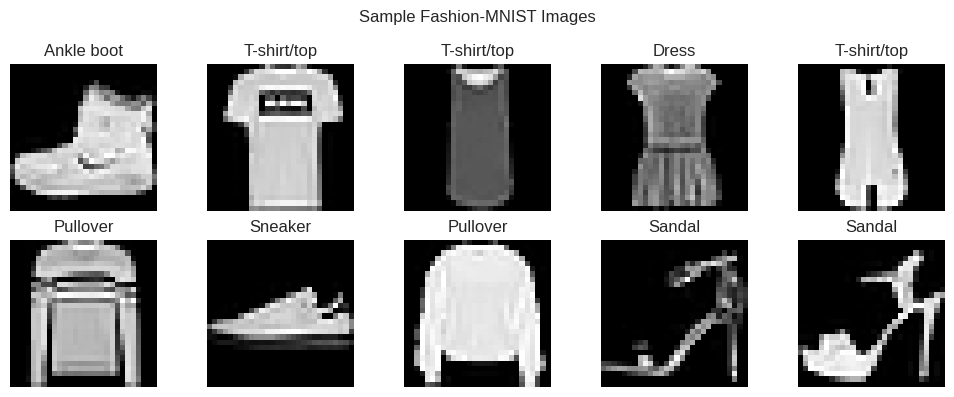

In [4]:
# 2. Visualize sample images
plt.figure(figsize=(10, 4))
for i in range(10):
    plt.subplot(2, 5, i + 1)
    plt.imshow(x_train[i], cmap="gray")
    plt.title(class_names[y_train[i]])
    plt.axis("off")
plt.suptitle("Sample Fashion-MNIST Images")
plt.tight_layout()
plt.show()

In [5]:
# 3. Preprocessing: normalization + reshape

# Scale pixel values from [0, 255] to [0, 1]
x_train = x_train.astype("float32") / 255.0
x_test = x_test.astype("float32") / 255.0

# Flatten 28x28 images into 784-dim vectors for a simple feedforward NN
x_train_flat = x_train.reshape((x_train.shape[0], -1))
x_test_flat = x_test.reshape((x_test.shape[0], -1))

print("Flattened train shape:", x_train_flat.shape)

Flattened train shape: (60000, 784)


In [6]:
# 4. Build a simple feedforward neural network

model = models.Sequential([
    layers.Input(shape=(784,)),                 # flattened 28x28
    layers.Dense(256, activation="relu"),
    layers.Dense(128, activation="relu"),
    layers.Dense(10, activation="softmax")      # 10 classes
])

model.summary()


Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ dense (Dense)                   │ (None, 256)            │       200,960 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 128)            │        32,896 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_2 (Dense)                 │ (None, 10)             │         1,290 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 235,146 (918.54 KB)

 Trainable params: 235,146 (918.54 KB)

 Non-trainable params: 0 (0.00 B)

In [7]:
# 5. Compile the model
model.compile(
    optimizer="adam",
    loss="sparse_categorical_crossentropy",
    metrics=["accuracy"]
)

In [8]:
# 6. Train the model

history = model.fit(
    x_train_flat,
    y_train,
    epochs=15,
    batch_size=64,
    validation_split=0.2,
    verbose=1
)

Epoch 1/15
750/750 ━━━━━━━━━━━━━━━━━━━━ 5s 5ms/step - accuracy: 0.8202 - loss: 0.5077 - val_accuracy: 0.8535 - val_loss: 0.4210
Epoch 2/15
750/750 ━━━━━━━━━━━━━━━━━━━━ 3s 4ms/step - accuracy: 0.8658 - loss: 0.3704 - val_accuracy: 0.8695 - val_loss: 0.3679
Epoch 3/15
750/750 ━━━━━━━━━━━━━━━━━━━━ 3s 4ms/step - accuracy: 0.8781 - loss: 0.3322 - val_accuracy: 0.8781 - val_loss: 0.3418
Epoch 4/15
750/750 ━━━━━━━━━━━━━━━━━━━━ 5s 4ms/step - accuracy: 0.8874 - loss: 0.3044 - val_accuracy: 0.8808 - val_loss: 0.3331
Epoch 5/15
750/750 ━━━━━━━━━━━━━━━━━━━━ 3s 4ms/step - accuracy: 0.8930 - loss: 0.2879 - val_accuracy: 0.8804 - val_loss: 0.3296
Epoch 6/15
750/750 ━━━━━━━━━━━━━━━━━━━━ 4s 5ms/step - accuracy: 0.8975 - loss: 0.2739 - val_accuracy: 0.8761 - val_loss: 0.3305
Epoch 7/15
750/750 ━━━━━━━━━━━━━━━━━━━━ 4s 5ms/step - accuracy: 0.9028 - loss: 0.2584 - val_accuracy: 0.8892 - val_loss: 0.3238
Epoch 8/15
750/750 ━━━━━━━━━━━━━━━━━━━━ 3s 5ms/step - accuracy: 0.9080 - loss: 0.2462 - val_accuracy: 0.

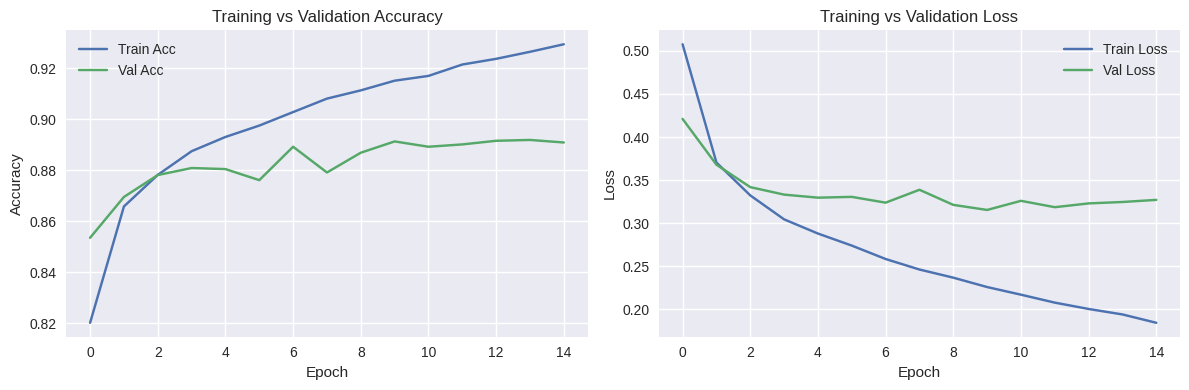

In [9]:
# 7. Plot training & validation accuracy/loss
def plot_history(history):
    hist = history.history

    plt.figure(figsize=(12,4))

    # Accuracy
    plt.subplot(1,2,1)
    plt.plot(hist["accuracy"], label="Train Acc")
    plt.plot(hist["val_accuracy"], label="Val Acc")
    plt.xlabel("Epoch")
    plt.ylabel("Accuracy")
    plt.title("Training vs Validation Accuracy")
    plt.legend()

    # Loss
    plt.subplot(1,2,2)
    plt.plot(hist["loss"], label="Train Loss")
    plt.plot(hist["val_loss"], label="Val Loss")
    plt.xlabel("Epoch")
    plt.ylabel("Loss")
    plt.title("Training vs Validation Loss")
    plt.legend()

    plt.tight_layout()
    plt.show()

plot_history(history)


In [10]:
# 8. Evaluate on test set
test_loss, test_acc = model.evaluate(x_test_flat, y_test, verbose=0)
print(f"Test accuracy: {test_acc:.4f}, Test loss: {test_loss:.4f}")


Test accuracy: 0.8858, Test loss: 0.3488


313/313 ━━━━━━━━━━━━━━━━━━━━ 0s 1ms/step
Classification Report:
              precision    recall  f1-score   support

 T-shirt/top       0.79      0.88      0.84      1000
     Trouser       0.99      0.96      0.98      1000
    Pullover       0.77      0.84      0.80      1000
       Dress       0.87      0.92      0.89      1000
        Coat       0.81      0.79      0.80      1000
      Sandal       0.98      0.96      0.97      1000
       Shirt       0.78      0.60      0.68      1000
     Sneaker       0.94      0.96      0.95      1000
         Bag       0.97      0.98      0.98      1000
  Ankle boot       0.96      0.95      0.96      1000

    accuracy                           0.89     10000
   macro avg       0.89      0.89      0.88     10000
weighted avg       0.89      0.89      0.88     10000



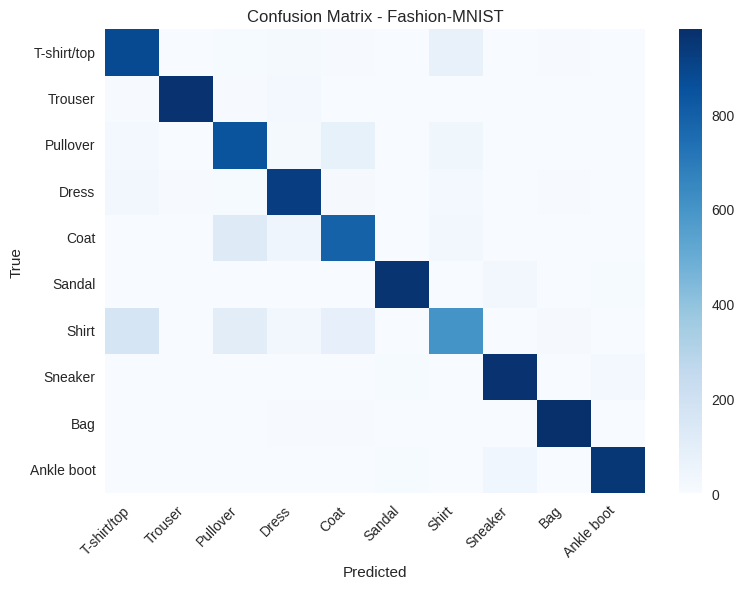

In [11]:
# 9. Classification report & confusion matrix

y_pred_probs = model.predict(x_test_flat)
y_pred = np.argmax(y_pred_probs, axis=1)

print("Classification Report:")
print(classification_report(y_test, y_pred, target_names=class_names))

cm = confusion_matrix(y_test, y_pred)

plt.figure(figsize=(8,6))
sns.heatmap(cm, annot=False, cmap="Blues",
            xticklabels=class_names,
            yticklabels=class_names)
plt.xlabel("Predicted")
plt.ylabel("True")
plt.title("Confusion Matrix - Fashion-MNIST")
plt.xticks(rotation=45, ha="right")
plt.yticks(rotation=0)
plt.tight_layout()
plt.show()
